# Diagnóstico de Câncer de Mama com Machine Learning

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

O câncer de mama é o tipo de câncer mais comum entre mulheres no mundo. A detecção precoce é fundamental para aumentar as chances de tratamento bem-sucedido. Neste notebook, vamos construir modelos de Machine Learning capazes de classificar tumores de mama como **malignos** ou **benignos** com base em características extraídas de imagens digitalizadas de aspiração por agulha fina (FNA) de massas mamárias.

### Dataset

Utilizaremos o **Wisconsin Breast Cancer Dataset**, disponível diretamente pelo scikit-learn. O dataset contém 569 amostras com 30 features numéricas extraídas de imagens de células, como raio médio, textura, perímetro, área, suavidade, entre outras.

### Objetivo

Treinar e comparar diferentes modelos de classificação para identificar qual apresenta o melhor desempenho no diagnóstico de câncer de mama, sempre lembrando que **o médico deve ter a palavra final** no diagnóstico.

---

## 1. Importação das Bibliotecas

Vamos começar importando as bibliotecas que serão utilizadas ao longo do notebook. Escolhemos ferramentas padrão do ecossistema Python para ciência de dados e ML.

In [ ]:
%pip install -r ../requirements.txt


In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import os

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelos e métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# SHAP para interpretabilidade
import shap

# Importar nossas funções auxiliares
import sys
sys.path.append('..')
from src.utils import (
    plotar_distribuicao_classes, plotar_histogramas, plotar_correlacao,
    plotar_matriz_confusao, plotar_curvas_roc_comparativas,
    avaliar_modelo, comparar_modelos, exibir_classification_report
)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Ignorar avisos para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Diretório para salvar os resultados (gráficos e tabelas)
DIR_RESULTADOS = os.path.join('..', 'resultados')
os.makedirs(DIR_RESULTADOS, exist_ok=True)
print(f"Gráficos serão salvos em: {os.path.abspath(DIR_RESULTADOS)}")

Gráficos serão salvos em: D:\tech-challenge-1-main\resultados


## 2. Carregamento e Exploração dos Dados (EDA)

Vamos carregar o dataset e entender sua estrutura. É importante conhecer bem os dados antes de qualquer modelagem — isso nos ajuda a tomar decisões melhores nas etapas seguintes.

### 2.1 Carregamento do Dataset

In [3]:
# Carregar o dataset de câncer de mama a partir do CSV
# O CSV foi gerado pelo script data/download_datasets.py
# Fonte original: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data

caminho_csv = os.path.join('..', 'data', 'cancer_mama.csv')

# Se o CSV ainda não existe, rodar o script de download
if not os.path.exists(caminho_csv):
    print("CSV não encontrado. Executando script de download...")
    sys.path.append(os.path.join('..', 'data'))
    from download_datasets import baixar_cancer_mama
    baixar_cancer_mama()

# Carregar o CSV
df = pd.read_csv(caminho_csv)

# Separar nomes das features (todas as colunas exceto 'diagnostico')
feature_names = [col for col in df.columns if col != 'diagnostico']

print(f"Dataset carregado de: {caminho_csv}")
print(f"Formato do dataset: {df.shape[0]} amostras e {df.shape[1]} colunas")
print(f"\nFeatures disponíveis: {feature_names}")
print(f"\nClasses: 0 = Maligno, 1 = Benigno")
df.head()

Dataset carregado de: ..\data\cancer_mama.csv
Formato do dataset: 569 amostras e 31 colunas

Features disponíveis: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Classes: 0 = Maligno, 1 = Benigno


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2.2 Informações Gerais do Dataset

Vamos verificar os tipos de dados, se há valores nulos e as estatísticas descritivas básicas.

In [4]:
# Informações gerais do DataFrame
print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smo

In [5]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum().to_string())
print(f"\nTotal de valores nulos no dataset: {df.isnull().sum().sum()}")

Valores nulos por coluna:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnostico                0

Total de valores nulos no dataset: 0


In [6]:
# Estatísticas descritivas
# Isso nos ajuda a entender a escala, a dispersão e a distribuição de cada feature
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 2.3 Distribuição das Classes

Uma etapa importante é verificar se as classes estão balanceadas. Se houver um desbalanceamento muito grande, os modelos podem ficar enviesados para a classe majoritária, o que seria perigoso em um contexto médico — imagine um modelo que "acerta muito" mas na verdade só classifica tudo como benigno.

  → Gráfico salvo em: ..\resultados\cm_distribuicao_classes.png


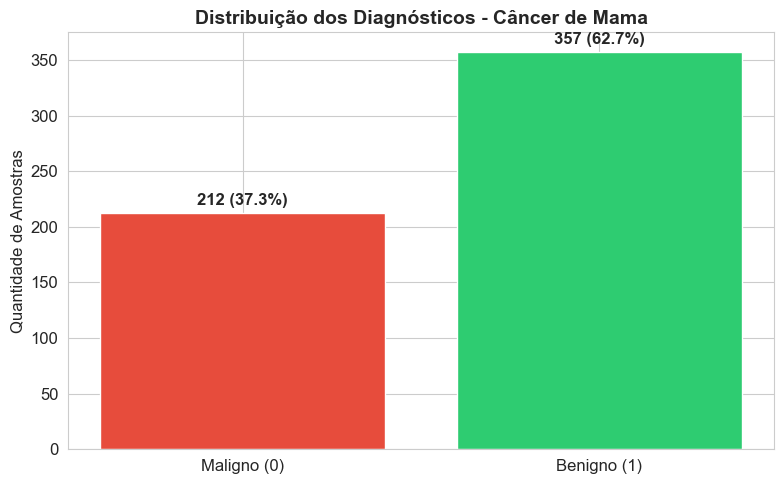

Proporção das classes:
  Maligno:  212 (37.3%)
  Benigno:  357 (62.7%)


In [7]:
# Distribuição das classes
# No dataset: 0 = maligno, 1 = benigno
plotar_distribuicao_classes(
    df['diagnostico'],
    nomes_classes=['Maligno (0)', 'Benigno (1)'],
    titulo='Distribuição dos Diagnósticos - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_distribuicao_classes.png')
)

# Proporção exata
print(f"Proporção das classes:")
print(f"  Maligno:  {(df['diagnostico'] == 0).sum()} ({(df['diagnostico'] == 0).mean()*100:.1f}%)")
print(f"  Benigno:  {(df['diagnostico'] == 1).sum()} ({(df['diagnostico'] == 1).mean()*100:.1f}%)")

**Análise:** O dataset apresenta um leve desbalanceamento (aproximadamente 63% benigno e 37% maligno), mas não é grave o suficiente para exigir técnicas de balanceamento como SMOTE. Vamos utilizar o parâmetro `stratify` na separação dos dados para manter essa proporção nos conjuntos de treino e teste.

### 2.4 Distribuição das Features

Vamos visualizar como as features se distribuem para entender melhor os dados e identificar possíveis outliers ou padrões.

Features 'mean' (médias): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']


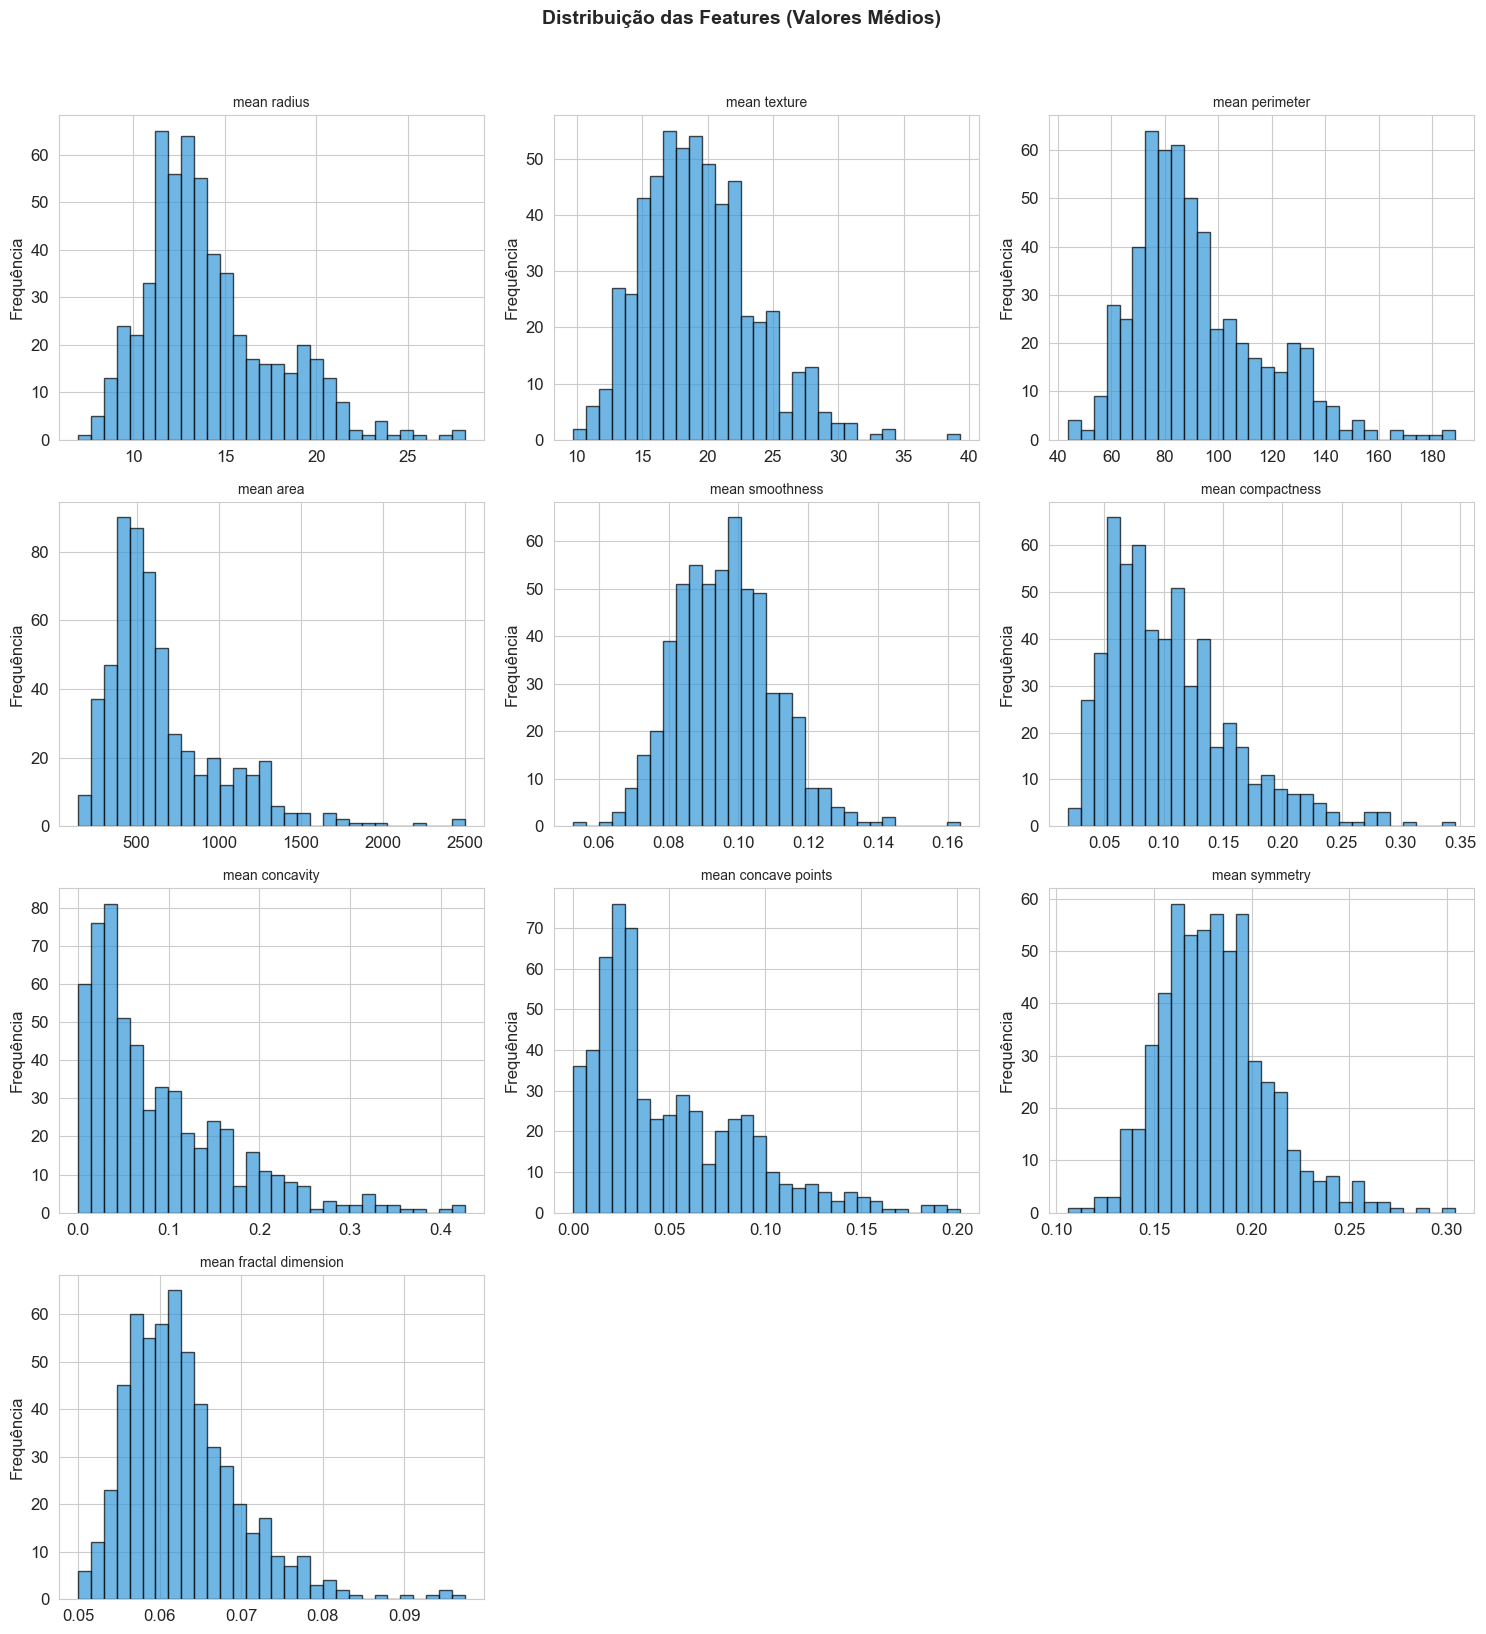

In [8]:
# Vamos visualizar as features que contêm "mean" (valores médios)
# O dataset tem 3 grupos de features: mean (média), se (erro padrão) e worst (pior valor)
features_mean = [col for col in feature_names if 'mean' in col]
print(f"Features 'mean' (médias): {features_mean}")

plotar_histogramas(df, features_mean, titulo='Distribuição das Features (Valores Médios)')

  → Gráfico salvo em: ..\resultados\cm_boxplots.png


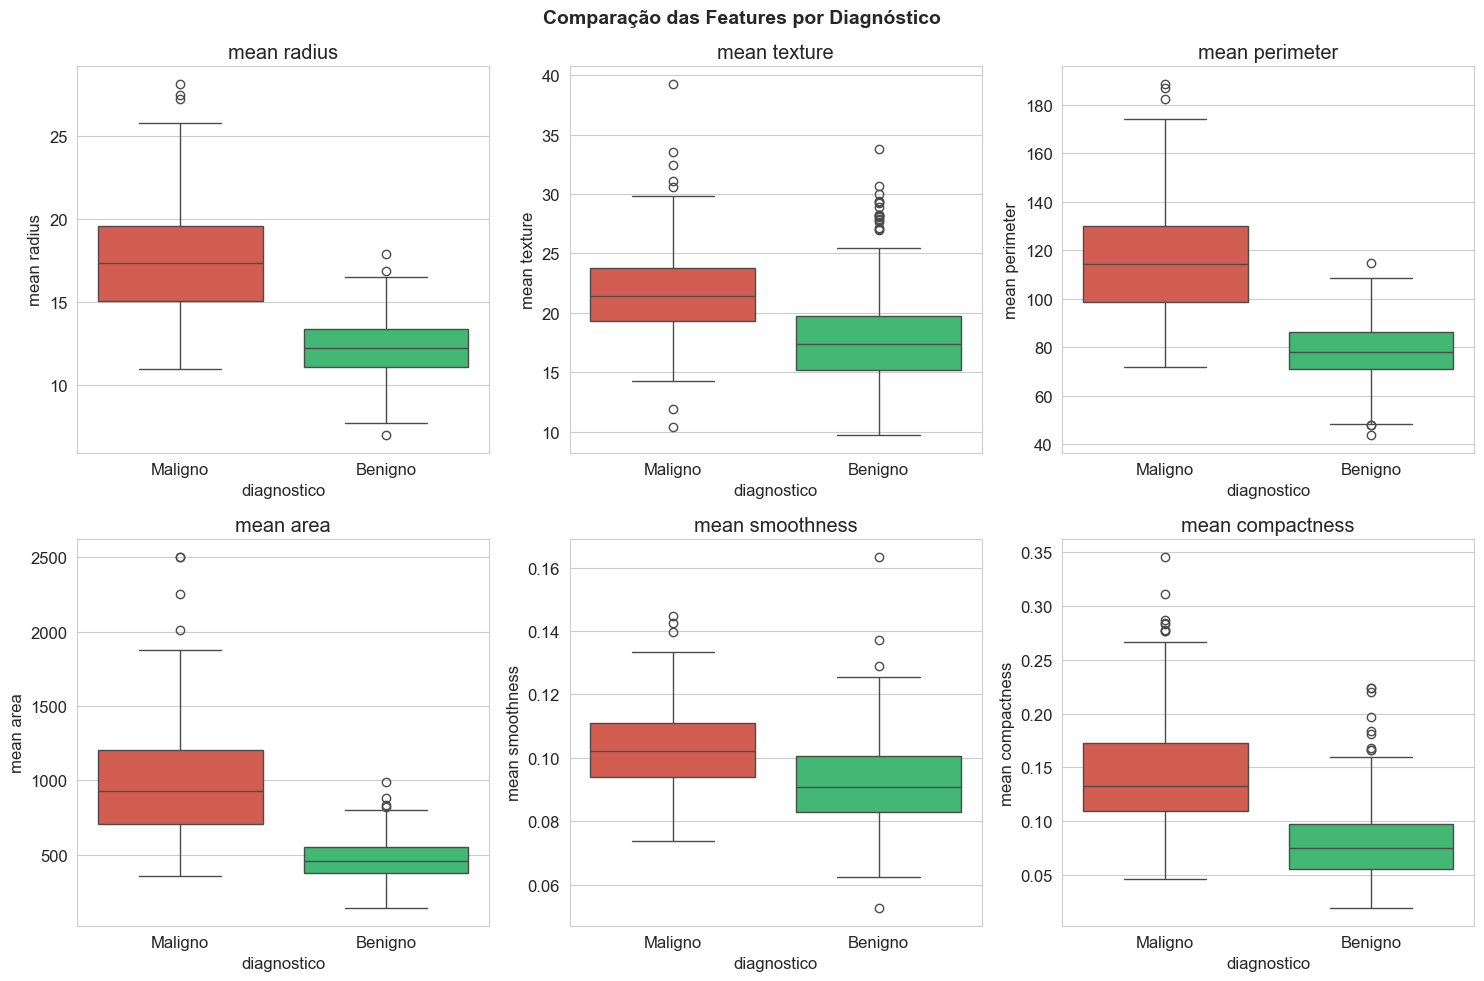

In [9]:
# Boxplots para comparar distribuições entre classes (maligno vs benigno)
# Vamos selecionar algumas features importantes para essa comparação
features_destaque = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                     'mean smoothness', 'mean compactness']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features_destaque):
    sns.boxplot(data=df, x='diagnostico', y=feature, ax=axes[i],
                palette=['#e74c3c', '#2ecc71'])
    axes[i].set_xticklabels(['Maligno', 'Benigno'])
    axes[i].set_title(feature)

fig.suptitle('Comparação das Features por Diagnóstico', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_boxplots.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_boxplots.png')}")
plt.show()

**Análise dos boxplots:** Podemos observar que features como `mean radius`, `mean perimeter` e `mean area` apresentam uma separação clara entre tumores malignos e benignos — tumores malignos tendem a ter valores maiores nessas medidas. Isso faz sentido biologicamente, pois tumores malignos geralmente crescem mais e de forma irregular. Já `mean smoothness` mostra menos separação, o que indica que pode ser menos útil para a classificação.

---

## 3. Pré-processamento dos Dados

Antes de treinar os modelos, precisamos preparar os dados adequadamente. Essa etapa inclui:
1. Separar features e variável alvo
2. Analisar correlações entre as features
3. Aplicar escalonamento (Feature Scaling)
4. Dividir em treino e teste

### 3.1 Análise de Correlação

Vamos analisar a correlação entre as features. Features muito correlacionadas entre si podem causar redundância, mas por enquanto vamos manter todas e observar como os modelos se comportam.

  → Gráfico salvo em: ..\resultados\cm_correlacao.png


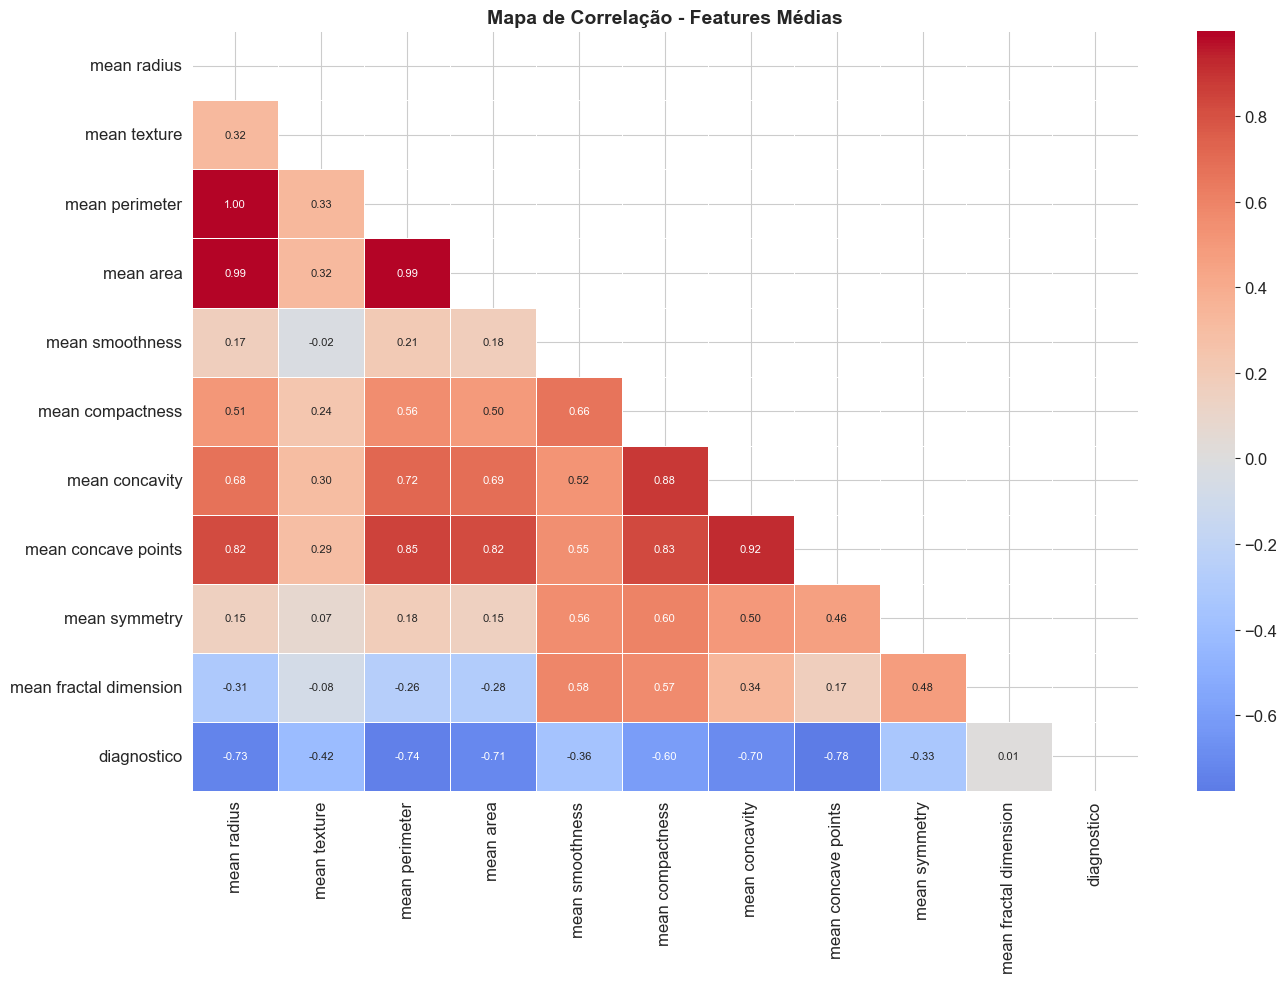

In [10]:
# Análise de correlação - vamos usar apenas as features 'mean' para o heatmap ficar legível
df_mean = df[features_mean + ['diagnostico']]
correlacao = plotar_correlacao(df_mean, titulo='Mapa de Correlação - Features Médias',
                        salvar_em=os.path.join(DIR_RESULTADOS, 'cm_correlacao.png'))

In [11]:
# Identificar pares de features com alta correlação (acima de 0.9)
# Isso nos ajuda a entender a redundância nos dados
correlacao_completa = df.drop('diagnostico', axis=1).corr()
pares_alta_corr = []

for i in range(len(correlacao_completa.columns)):
    for j in range(i + 1, len(correlacao_completa.columns)):
        if abs(correlacao_completa.iloc[i, j]) > 0.9:
            pares_alta_corr.append({
                'Feature 1': correlacao_completa.columns[i],
                'Feature 2': correlacao_completa.columns[j],
                'Correlação': correlacao_completa.iloc[i, j]
            })

df_corr = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)
print(f"Pares de features com correlação acima de 0.9: {len(df_corr)}")
df_corr

Pares de features com correlação acima de 0.9: 21


,Feature 1,Feature 2,Correlação
0,mean radius,mean perimeter,0.997855
18,worst radius,worst perimeter,0.993708
1,mean radius,mean area,0.987357
6,mean perimeter,mean area,0.986507
19,worst radius,worst area,0.984015
20,worst perimeter,worst area,0.977578
15,radius error,perimeter error,0.972794
8,mean perimeter,worst perimeter,0.970387
2,mean radius,worst radius,0.969539
7,mean perimeter,worst radius,0.969476


**Análise da correlação:** Existem vários pares de features altamente correlacionadas, como `mean radius`, `mean perimeter` e `mean area` — o que faz sentido, pois raio, perímetro e área de um círculo são matematicamente relacionados. Essa redundância não impede os modelos de funcionar, mas é algo a se considerar em trabalhos futuros (por exemplo, usando PCA para redução de dimensionalidade).

### 3.2 Separação dos Dados e Feature Scaling

Agora vamos separar as features (X) da variável alvo (y), dividir em treino e teste, e aplicar escalonamento.

**Por que escalonar os dados?** Algoritmos como KNN e Regressão Logística são sensíveis à escala das features. Se uma feature varia de 0 a 1 e outra de 0 a 1000, a segunda vai dominar o cálculo de distância. Vamos testar dois escaladores para ver qual funciona melhor:
- **StandardScaler**: transforma os dados para média 0 e desvio padrão 1
- **MinMaxScaler**: transforma os dados para o intervalo [0, 1]

In [12]:
# Separar features (X) e variável alvo (y)
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

# Dividir em treino e teste (80/20)
# Usamos stratify=y para manter a proporção das classes em ambos os conjuntos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_treino.shape[0]} amostras")
print(f"Conjunto de teste:  {X_teste.shape[0]} amostras")
print(f"\nProporção das classes no treino:")
print(f"  Maligno: {(y_treino == 0).sum()} ({(y_treino == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_treino == 1).sum()} ({(y_treino == 1).mean()*100:.1f}%)")
print(f"\nProporção das classes no teste:")
print(f"  Maligno: {(y_teste == 0).sum()} ({(y_teste == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_teste == 1).sum()} ({(y_teste == 1).mean()*100:.1f}%)")

Conjunto de treino: 455 amostras
Conjunto de teste:  114 amostras

Proporção das classes no treino:
  Maligno: 170 (37.4%)
  Benigno: 285 (62.6%)

Proporção das classes no teste:
  Maligno: 42 (36.8%)
  Benigno: 72 (63.2%)


### 3.3 Comparação de Escaladores: StandardScaler vs MinMaxScaler

Antes de definir qual escalador usar, vamos testar ambos com um modelo simples (Regressão Logística) para ver qual produz melhores resultados. Essa é uma boa prática: ao invés de escolher arbitrariamente, deixamos os dados nos mostrarem qual funciona melhor.

In [13]:
# Comparar StandardScaler vs MinMaxScaler usando validação cruzada
# Usamos Pipeline para garantir que o escalonamento é feito corretamente
# (ajustado no treino, aplicado no teste — evita data leakage)

# Pipeline com StandardScaler
pipeline_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Pipeline com MinMaxScaler
pipeline_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Validação cruzada com 5 folds
scores_standard = cross_val_score(pipeline_standard, X_treino, y_treino, cv=5, scoring='f1_weighted')
scores_minmax = cross_val_score(pipeline_minmax, X_treino, y_treino, cv=5, scoring='f1_weighted')

print("Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)")
print("=" * 65)
print(f"StandardScaler: {scores_standard.mean():.4f} (+/- {scores_standard.std():.4f})")
print(f"MinMaxScaler:   {scores_minmax.mean():.4f} (+/- {scores_minmax.std():.4f})")

if scores_standard.mean() > scores_minmax.mean():
    print(f"\n→ StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = StandardScaler()
    nome_scaler = "StandardScaler"
else:
    print(f"\n→ MinMaxScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = MinMaxScaler()
    nome_scaler = "MinMaxScaler"

Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)
StandardScaler: 0.9801 (+/- 0.0129)
MinMaxScaler:   0.9711 (+/- 0.0194)

→ StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.


In [14]:
# Aplicar o escalador escolhido nos dados
scaler = scaler_escolhido
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)  # Apenas transform, sem fit!

print(f"Escalador utilizado: {nome_scaler}")
print(f"Shape dos dados de treino escalonados: {X_treino_scaled.shape}")
print(f"Shape dos dados de teste escalonados: {X_teste_scaled.shape}")

Escalador utilizado: StandardScaler
Shape dos dados de treino escalonados: (455, 30)
Shape dos dados de teste escalonados: (114, 30)


---

## 4. Modelagem

Agora vamos treinar três modelos de classificação diferentes. A ideia é comparar abordagens distintas para entender qual se adapta melhor ao nosso problema:

1. **Regressão Logística** — modelo linear simples e interpretável, bom como baseline. Apesar do nome "regressão", é usado para classificação. Funciona bem quando as classes são linearmente separáveis.

2. **KNN (K-Nearest Neighbors)** — classifica com base na "vizinhança" de cada amostra. A ideia é simples: se os vizinhos mais próximos de um ponto são malignos, ele provavelmente é maligno. É sensível à escala dos dados (por isso o escalonamento é importante).

3. **Árvore de Decisão** — cria regras de decisão do tipo "se feature X > valor, então...". É muito interpretável e nos permite entender quais features o modelo considera mais importantes.

### 4.1 Modelo 1: Regressão Logística

REGRESSÃO LOGÍSTICA - Classification Report
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  → Gráfico salvo em: ..\resultados\cm_mc_regressao_logistica.png


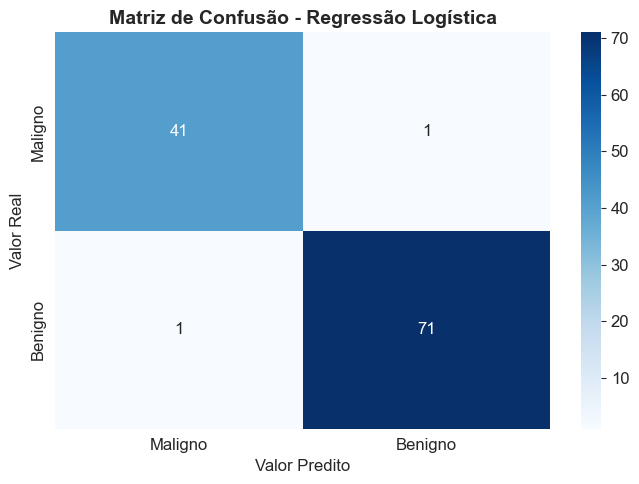

In [15]:
# Modelo 1: Regressão Logística
# Escolhemos este modelo como baseline por ser simples e rápido
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_treino_scaled, y_treino)

# Predições
y_pred_lr = modelo_lr.predict(X_teste_scaled)
y_prob_lr = modelo_lr.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("REGRESSÃO LOGÍSTICA - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_lr, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_lr, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Regressão Logística',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_regressao_logistica.png'))

### 4.2 Modelo 2: KNN (K-Nearest Neighbors)

Para o KNN, precisamos definir o número de vizinhos (K). Vamos testar diferentes valores para encontrar o melhor.

  → Gráfico salvo em: ..\resultados\cm_melhor_k.png


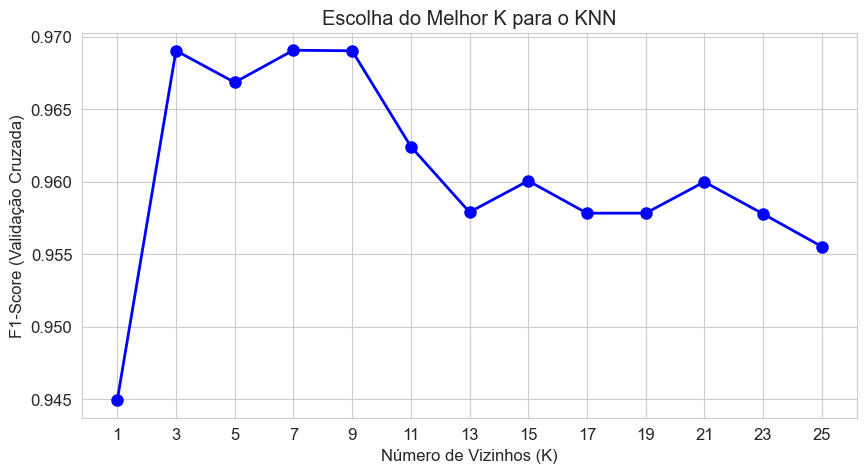

Melhor valor de K: 7 (F1-Score: 0.9691)


In [16]:
# Encontrar o melhor valor de K usando validação cruzada
# Testamos valores ímpares de 1 a 25 para evitar empates na votação
valores_k = range(1, 26, 2)
scores_k = []

for k in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_treino_scaled, y_treino, cv=5, scoring='f1_weighted')
    scores_k.append(scores.mean())

# Plotar resultado
plt.figure(figsize=(10, 5))
plt.plot(list(valores_k), scores_k, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('F1-Score (Validação Cruzada)')
plt.title('Escolha do Melhor K para o KNN')
plt.xticks(list(valores_k))
plt.grid(True)
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png')}")
plt.show()

melhor_k = list(valores_k)[np.argmax(scores_k)]
print(f"Melhor valor de K: {melhor_k} (F1-Score: {max(scores_k):.4f})")

KNN (K=7) - Classification Report
              precision    recall  f1-score   support

     Maligno       1.00      0.93      0.96        42
     Benigno       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

  → Gráfico salvo em: ..\resultados\cm_mc_knn.png


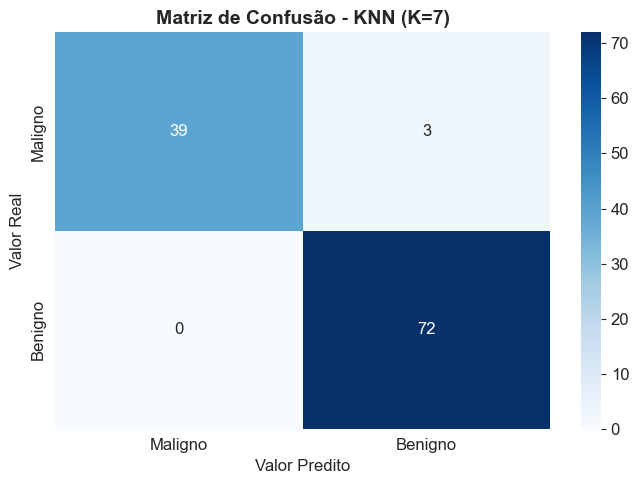

In [17]:
# Modelo 2: KNN com o melhor K encontrado
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_treino_scaled, y_treino)

# Predições
y_pred_knn = modelo_knn.predict(X_teste_scaled)
y_prob_knn = modelo_knn.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print(f"KNN (K={melhor_k}) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_knn, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_knn, ['Maligno', 'Benigno'],
                       titulo=f'Matriz de Confusão - KNN (K={melhor_k})',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_knn.png'))

### 4.3 Modelo 3: Árvore de Decisão

A Árvore de Decisão é um modelo que cria regras de decisão hierárquicas. Uma vantagem é que não precisa de escalonamento dos dados, mas vamos usar os dados escalonados para manter a consistência na comparação.

ÁRVORE DE DECISÃO - Classification Report
              precision    recall  f1-score   support

     Maligno       0.87      0.93      0.90        42
     Benigno       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114

  → Gráfico salvo em: ..\resultados\cm_mc_arvore_decisao.png


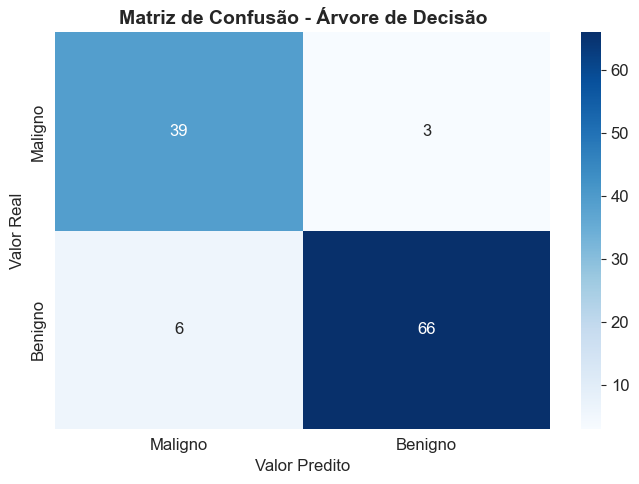

In [18]:
# Modelo 3: Árvore de Decisão
# Limitamos a profundidade para evitar overfitting
modelo_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino_scaled, y_treino)

# Predições
y_pred_arvore = modelo_arvore.predict(X_teste_scaled)
y_prob_arvore = modelo_arvore.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("ÁRVORE DE DECISÃO - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_arvore, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_arvore, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Árvore de Decisão',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_arvore_decisao.png'))

---

## 5. Avaliação Comparativa dos Modelos

Agora vamos comparar os três modelos lado a lado para entender qual teve o melhor desempenho. 

### 5.1 Tabela Comparativa de Métricas

**Sobre a escolha da métrica principal:** Em um problema de diagnóstico de câncer, o **recall** (sensibilidade) é a métrica mais importante. Um falso negativo (classificar um tumor maligno como benigno) é muito mais perigoso do que um falso positivo (classificar um benigno como maligno). No primeiro caso, o paciente pode não receber o tratamento necessário; no segundo, exames adicionais serão realizados para confirmar.

In [19]:
# Calcular métricas para cada modelo
metricas_lr = avaliar_modelo(y_teste, y_pred_lr, 'Regressão Logística')
metricas_knn = avaliar_modelo(y_teste, y_pred_knn, f'KNN (K={melhor_k})')
metricas_arvore = avaliar_modelo(y_teste, y_pred_arvore, 'Árvore de Decisão')

# Tabela comparativa
lista_metricas = [metricas_lr, metricas_knn, metricas_arvore]
df_comparacao, df_formatado = comparar_modelos(lista_metricas)

print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(df_comparacao.to_string())
print()

# Identificar o melhor modelo pelo recall (métrica mais importante neste caso)
melhor_recall = df_comparacao['Recall'].idxmax()
print(f"→ Melhor modelo considerando Recall: {melhor_recall}")
print(f"  Recall = {df_comparacao.loc[melhor_recall, 'Recall']:.4f}")

# Exibir tabela formatada
df_formatado

COMPARAÇÃO DOS MODELOS
                     Acurácia  Precisão    Recall  F1-Score
Modelo                                                     
Regressão Logística  0.982456  0.982456  0.982456  0.982456
KNN (K=7)            0.973684  0.974737  0.973684  0.973465
Árvore de Decisão    0.921053  0.923417  0.921053  0.921574

→ Melhor modelo considerando Recall: Regressão Logística
  Recall = 0.9825


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
Regressão Logística,0.9825,0.9825,0.9825,0.9825
KNN (K=7),0.9737,0.9747,0.9737,0.9735
Árvore de Decisão,0.9211,0.9234,0.9211,0.9216


### 5.2 Validação Cruzada

Para ter uma avaliação mais robusta, vamos usar validação cruzada (5-fold) em cada modelo. Isso reduz o risco de termos resultados que dependem de uma divisão específica dos dados.

VALIDAÇÃO CRUZADA (5-Fold)
Regressão Logística      : Recall = 0.9807 (+/- 0.0065)
KNN (K=7)                : Recall = 0.9701 (+/- 0.0089)
Árvore de Decisão        : Recall = 0.9191 (+/- 0.0180)
  → Gráfico salvo em: ..\resultados\cm_validacao_cruzada.png


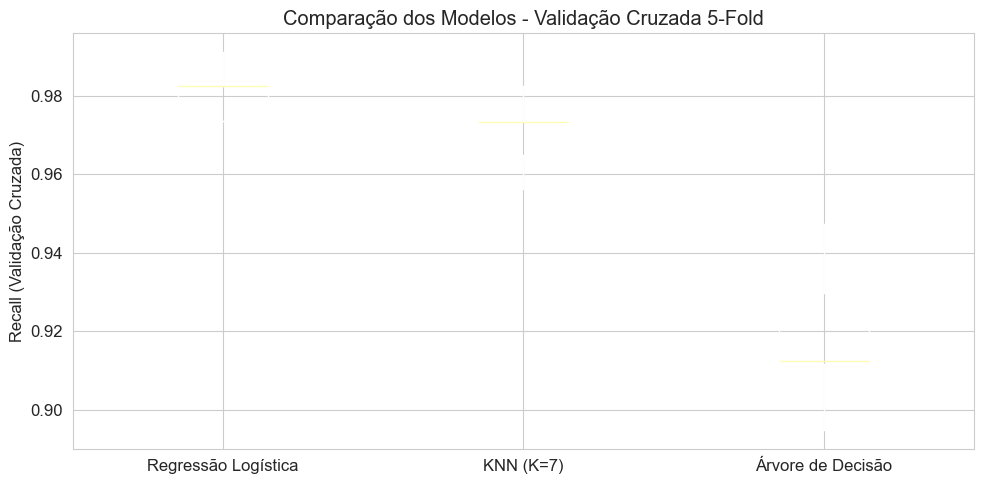

In [20]:
# Validação cruzada com 5 folds para cada modelo
# Usamos Pipeline para integrar o escalonamento na validação cruzada

modelos_cv = {
    'Regressão Logística': LogisticRegression(max_iter=10000, random_state=42),
    f'KNN (K={melhor_k})': KNeighborsClassifier(n_neighbors=melhor_k),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42)
}

print("VALIDAÇÃO CRUZADA (5-Fold)")
print("=" * 60)

resultados_cv = {}
for nome, modelo in modelos_cv.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', modelo)
    ])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='recall_weighted')
    resultados_cv[nome] = scores
    print(f"{nome:25s}: Recall = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Visualizar em boxplot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
ax.set_ylabel('Recall (Validação Cruzada)')
ax.set_title('Comparação dos Modelos - Validação Cruzada 5-Fold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png')}")
plt.show()

### 5.3 Curvas ROC

A curva ROC (Receiver Operating Characteristic) nos permite visualizar o trade-off entre a taxa de verdadeiros positivos e a taxa de falsos positivos. Quanto mais próxima a curva do canto superior esquerdo, melhor o modelo. A área sob a curva (AUC) resume esse desempenho em um único número.

  → Gráfico salvo em: ..\resultados\cm_curvas_roc.png


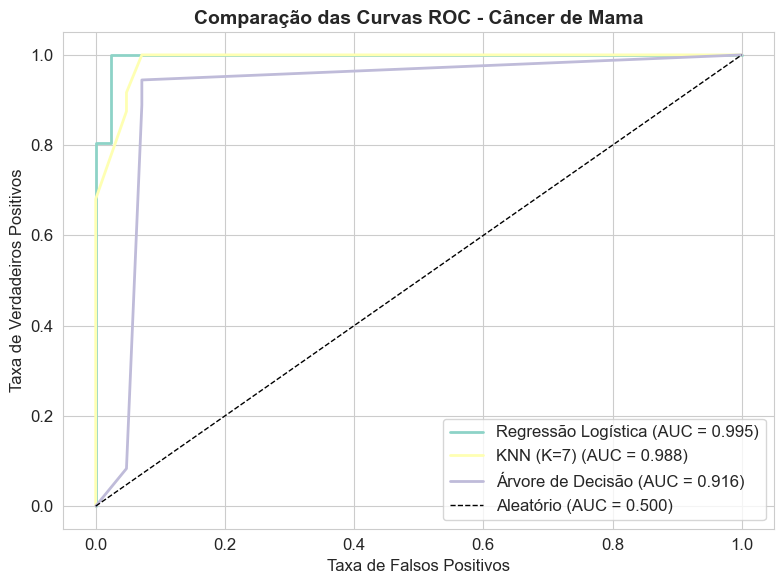

In [21]:
# Plotar curvas ROC comparativas
resultados_roc = {
    'Regressão Logística': y_prob_lr,
    f'KNN (K={melhor_k})': y_prob_knn,
    'Árvore de Decisão': y_prob_arvore
}

plotar_curvas_roc_comparativas(
    y_teste, resultados_roc,
    titulo='Comparação das Curvas ROC - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_curvas_roc.png')
)

---

## 6. Interpretação dos Resultados

Além de saber que um modelo funciona bem, é importante entender **por que** ele faz determinadas predições. Isso é especialmente crítico na área médica, onde o modelo precisa ser explicável para que os médicos confiem nas suas sugestões.

### 6.1 Feature Importance (Árvore de Decisão)

A Árvore de Decisão nos dá uma medida direta de importância de cada feature: quanto cada uma contribui para a separação das classes.

  → Gráfico salvo em: ..\resultados\cm_feature_importance.png


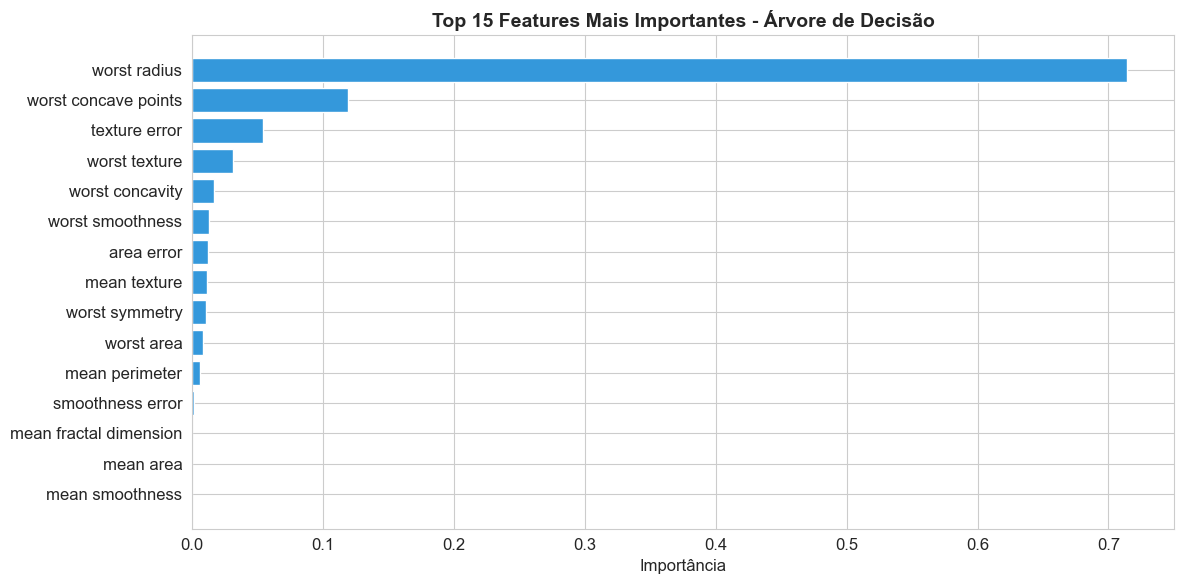

Top 10 Features mais importantes:
  1. worst radius                   - Importância: 0.7143
  2. worst concave points           - Importância: 0.1188
  3. texture error                  - Importância: 0.0539
  4. worst texture                  - Importância: 0.0315
  5. worst concavity                - Importância: 0.0167
  6. worst smoothness               - Importância: 0.0130
  7. area error                     - Importância: 0.0124
  8. mean texture                   - Importância: 0.0115
  9. worst symmetry                 - Importância: 0.0110
  10. worst area                     - Importância: 0.0087


In [22]:
# Feature Importance da Árvore de Decisão
importancias = modelo_arvore.feature_importances_
indices = np.argsort(importancias)[::-1]

# Plotar as 15 features mais importantes
top_n = 15
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), importancias[indices[:top_n]][::-1], color='#3498db')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in indices[:top_n]][::-1])
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features Mais Importantes - Árvore de Decisão', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png')}")
plt.show()

# Exibir valores
print("Top 10 Features mais importantes:")
for i in range(10):
    print(f"  {i+1}. {feature_names[indices[i]]:30s} - Importância: {importancias[indices[i]]:.4f}")

### 6.2 SHAP Values

SHAP (SHapley Additive exPlanations) é uma técnica que nos permite entender a contribuição de cada feature para cada predição individual. Diferente da feature importance que dá uma visão global, o SHAP mostra como cada feature influencia a predição para cada amostra.

Vamos aplicar o SHAP no modelo de Árvore de Decisão para entender suas decisões.

SHAP Summary Plot - Árvore de Decisão
Cada ponto é uma amostra. Cor vermelha = valor alto da feature, azul = valor baixo.
Posição à direita = contribui para classificar como benigno.

  → Gráfico salvo em: ..\resultados\cm_shap_summary.png


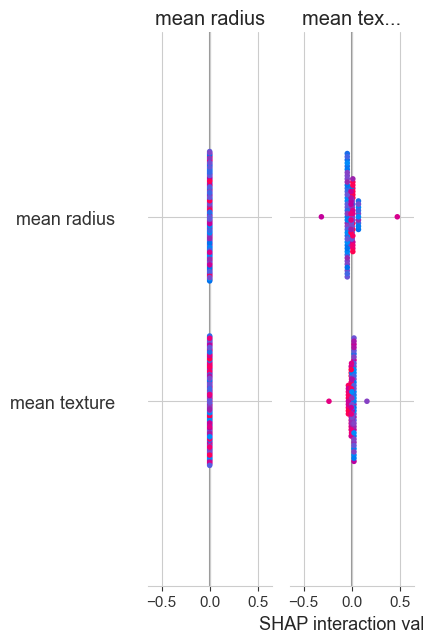

In [23]:
# SHAP - Interpretabilidade do modelo de Árvore de Decisão
# Usamos TreeExplainer pois é otimizado para modelos baseados em árvores

explainer = shap.TreeExplainer(modelo_arvore)
shap_values = explainer.shap_values(X_teste_scaled)

# Summary plot - mostra a importância e o efeito de cada feature
print("SHAP Summary Plot - Árvore de Decisão")
print("Cada ponto é uma amostra. Cor vermelha = valor alto da feature, azul = valor baixo.")
print("Posição à direita = contribui para classificar como benigno.")
print()

# Converter para numpy array (necessário para indexação do SHAP)
feature_names_array = np.array(feature_names)

# Para classificação binária, pegamos os shap_values da classe 1 (benigno)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=feature_names_array,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_shap_summary.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_shap_summary.png')}")
plt.show()

  → Gráfico salvo em: ..\resultados\cm_shap_bar.png


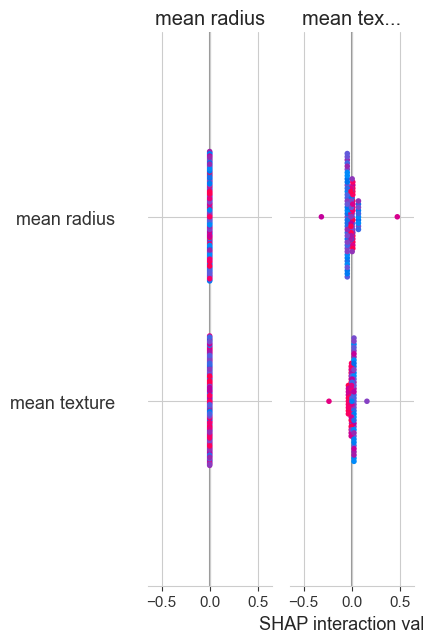

In [24]:
# SHAP Bar Plot - visão resumida da importância média de cada feature
shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=feature_names_array,
    plot_type='bar',
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_shap_bar.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_shap_bar.png')}")
plt.show()

**Interpretação do SHAP:** Os gráficos SHAP confirmam que features como `worst perimeter`, `worst concave points` e `mean concave points` são as mais influentes na classificação. Isso é consistente com o conhecimento médico: tumores malignos tendem a ter bordas irregulares (alto perímetro) e mais pontos côncavos (indicando forma irregular da célula).

---

## 7. Discussão Crítica

### O modelo pode ser utilizado na prática?

Os modelos apresentaram bons resultados nas métricas de avaliação, especialmente a Regressão Logística e o KNN. No entanto, é fundamental considerar os seguintes pontos:

**Pontos fortes:**
- Altas taxas de recall, o que é crucial em diagnósticos médicos (minimizar falsos negativos)
- O modelo é capaz de destacar quais características são mais relevantes para o diagnóstico
- O processamento é rápido e pode auxiliar na triagem de exames

**Limitações:**
- O dataset é relativamente pequeno (569 amostras). Em um cenário real, seria necessário treinar com muito mais dados
- Os dados são limpos e bem estruturados, o que raramente acontece em dados reais de hospitais
- O modelo trabalha apenas com features numéricas extraídas — não analisa as imagens diretamente

**O papel do médico:**
É essencial ressaltar que **o médico sempre deve ter a palavra final no diagnóstico**. O modelo de ML deve ser visto como uma **ferramenta de apoio**, não como um substituto do profissional. Ele pode:
- Auxiliar na triagem rápida de exames
- Chamar a atenção para casos que merecem análise mais cuidadosa
- Servir como "segunda opinião" automatizada

Mas a decisão final, considerando o histórico do paciente, exame clínico e outros fatores, sempre será do médico.

---

*Notebook desenvolvido como parte do Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs*

## Justificativa das Métricas

Neste problema, o objetivo principal é identificar corretamente casos de câncer.  
Por isso, a métrica **recall** é mais importante do que a acurácia, pois reduz a quantidade de falsos negativos.

A AUC também é utilizada para avaliar a capacidade geral do modelo.


## Matriz de Confusão

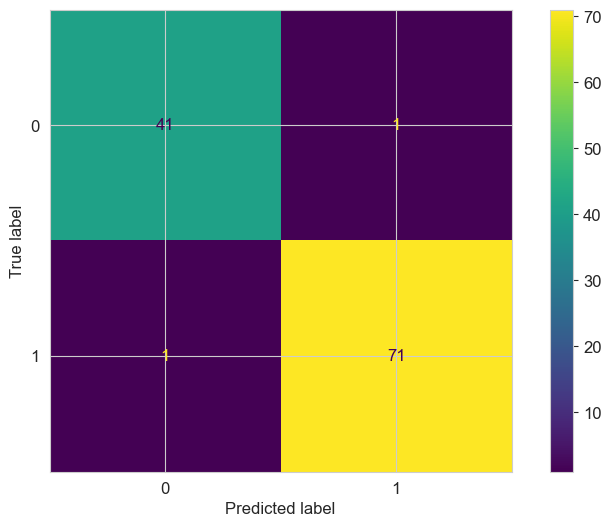

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_teste, y_pred_lr)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

A matriz de confusão ajuda a entender os erros do modelo, principalmente os falsos negativos, que são críticos neste problema.

## Análise de Erros

In [26]:
erros = X_teste[y_teste != y_pred_lr]
erros.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
541,14.47,24.99,95.81,656.4,0.08837,0.123,0.10090,0.03890,0.1872,0.06341,...,16.22,31.73,113.5,808.9,0.1340,0.4202,0.4040,0.1205,0.3187,0.1023
73,13.80,15.79,90.43,584.1,0.10070,0.128,0.07789,0.05069,0.1662,0.06566,...,16.57,20.86,110.3,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.1030


Permite identificar padrões onde o modelo erra.

## Observação sobre Correlação

Algumas variáveis possuem alta correlação.  
Neste trabalho, mantivemos as variáveis para preservar interpretabilidade.


## Conclusão

A Regressão Logística apresentou melhor equilíbrio entre recall e AUC.

Como o foco é reduzir falsos negativos, o recall foi priorizado.

O modelo pode ser usado como apoio à decisão médica, mas não substitui especialistas.
